## 1. Baseline Results Summary

Summarises results and progress for the four baseline models built so far: Chapman-Richards,
average-by-age, linear regression, and random forest, for both the 4survey and 6survey cohorts.

This notebook only reads already-saved results from `outputs/` (`metrics.json`,
`predictions.csv`) — it does not refit or re-evaluate anything. To regenerate the underlying
results, run `python -m models.baselines.run_baselines` then `python -m models.baselines.evaluate_baselines`.

### What the metrics mean and how to read them

Every table and chart in this notebook uses the same seven metrics, computed by
`models/common/metrics.py`. All are calculated on the **held-out test split only** — none of these
models ever see test rows during fitting.

| Metric | Units | Range | What it measures |
|---|---|---|---|
| **MAE** (Mean Absolute Error) | metres | 0 → ∞, lower is better | Average size of the error, ignoring direction. A MAE of 4m means predictions are, on average, 4m off from the true height — the single most intuitive "how wrong is this, typically" number. |
| **RMSE** (Root Mean Squared Error) | metres | 0 → ∞, lower is better | Like MAE, but squares each error before averaging, then takes the square root. This penalises large errors much more than small ones — RMSE is always ≥ MAE, and the *gap* between them tells you how much a few big misses are dragging the score down (RMSE ≫ MAE means a handful of large outlier errors, not many small ones). |
| **MSE** (Mean Squared Error) | metres² | 0 → ∞, lower is better | RMSE before the square root. Squared units make it hard to interpret directly, but it's what least-squares fitting (Chapman-Richards, linear regression) actually minimises, and it's what R² is built from. |
| **R²** (coefficient of determination) | unitless | −∞ → 1, higher is better | The fraction of the variation in observed height this model explains, relative to the simplest possible baseline (always predicting the mean height). 1.0 = perfect. 0.0 = no better than guessing the mean every time. **Negative is possible and means the model is worse than that trivial guess** — seen for real in this notebook (`average_by_age` under `temporal_split`, section 10). |
| **MRE** (Mean Relative Error) | unitless (fraction) | 0 → ∞, lower is better | Average of `\|error\| / observed height` — an error expressed as a proportion of the true height rather than metres. Useful for comparing error magnitude across very different tree sizes, but inflates for short/young plots (the same 2m error is 40% of a 5m sapling but 5% of a 40m mature tree) — see the age-banded caution in section 7. |
| **Accuracy_pct** | percentage | −∞ → 100%, higher is better | Just `(1 − MRE) × 100`. Same information as MRE, flipped to read as "percent accurate" rather than "percent error" — same caveats apply. |
| **Bias** | metres | −∞ → ∞, 0 is unbiased | Mean of `(observed − predicted)`, **signed**, not an error-size metric. Positive = the model tends to *under*-predict height on average; negative = *over*-predicts. A Bias near zero does **not** mean the model is accurate — large positive and negative errors can cancel out and still average to zero. Always read Bias alongside MAE/RMSE, never alone. |

### Which is my most important metric?

**RMSE is the best single headline number for this project**, for three reasons: it's in the
target's natural units (metres, directly meaningful for a forestry height prediction), it
penalises the large errors that matter most for the generalisation questions this dissertation is
actually asking (a model that's usually fine but occasionally wildly wrong is a bigger problem than
one that's consistently mediocre), and it's already the metric section 10's whole generalisation
comparison is built around — using it as the primary number elsewhere keeps every comparison in
this notebook consistent.

Two others matter enough to always check alongside it, not instead of it:
- **R²** is the fastest way to spot a model that has *failed outright*, not just underperformed —
  it's what first flagged `average_by_age` breaking under `temporal_split` (negative R²), a failure
  that RMSE alone states as "quite high" without making clear it's worse than a trivial baseline.
- **Bias** is what actually diagnoses *why* a model is wrong for this dissertation's specific
  story — the recurring theme across sections 9-10 isn't just "how big is the error" but "does this
  model systematically mis-predict a particular era or age range" (the survey-year confound,
  older-stand under-prediction). RMSE tells you a model is struggling; Bias tells you in which
  direction and where.

**On loss functions:** none of these four models need one, and none are shown here. "Loss
function" in the usual sense (an iterative training loop with a loss curve to check convergence
over epochs) only applies to models trained by gradient descent. None of these four are:
Chapman-Richards and linear regression are single least-squares solves, average-by-age is a
groupby-mean with no optimisation step at all, and random forest builds trees by greedy variance
reduction, not epochs. There is nothing to plot. This becomes relevant again once the DNN/PINN work
starts (see `outputs/dnn_noenv/`, `outputs/pinn_noenv/` — not yet included in this notebook).

In [41]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [42]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import (
    plot_bias_by_year,
    plot_error_by_age,
    plot_growth_curve,
    plot_predicted_vs_observed,
    plot_residuals,
)

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
MODEL_NAMES = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]
MODEL_COLORS = {
    "chapman_richards": "#1f77b4",
    "average_by_age": "#ff7f0e",
    "linear_baseline": "#2ca02c",
    "rf_baseline": "#d62728",
}

## 2. Experimental design: three ways of testing generalization

Every result in this notebook depends on **which rows get held out as "test"** — a model can look
excellent under an easy split and fall apart under a harder one, so before reading any results, it
matters to know what question each split is actually asking.

| Split | Question | Mechanism |
|---|---|---|
| `plot_level_split` | Can the model interpolate between plots it's seen the general neighbourhood of? | Individual **plots** shuffled randomly into train/val/test (60/20/20) — a held-out plot's nearest neighbour is usually a training plot metres away. |
| `spatial_block_split` | Does the model generalise to genuinely unseen **places**? | Whole forestry **compartments** (`cpmt`, 296 of them) assigned to train/val/test together, with a 60m buffer removing training plots too close to a held-out boundary. A held-out plot's nearest training neighbour can be kilometres away. |
| `temporal_split` | Does the model generalise to unseen **time** — a real future survey? | Whole **survey years** assigned to train/val/test (train: earliest years, val: 2021, test: 2023). The SAME plot can appear in both train and test, just at a different age — expected, not a leak, since the question here is about time, not about unseen plots or places. |

Sections 3-9 below use `plot_level_split` only (the easiest of the three) — section 10 runs the
same four baselines under all three, showing how differently they behave once the split gets
harder. See `documentation/experiment_log.md` for the full record of which configuration each
result came from, including planned robustness checks not yet run (e.g. a shorter-horizon version
of `temporal_split`).

The plot below shows the *mechanics* of each split directly — not model performance, just which
plots/years land in which bucket.

In [ ]:
from models.common.geo import load_plot_coordinates

SPLIT_COLORS = {
    "train": "#4c72b0", "val": "#dd8452", "test": "#c44e52",
    "buffer": "#c7c7c7", "unassigned": "#c7c7c7",
}


def split_assignment_path(cohort, split_type):
    # Small local copy of output_dir()'s split_type branching (defined
    # properly, and reused, in section 10 below) -- kept self-contained here
    # since this cell intentionally runs before that section.
    if split_type in ("spatial_block", "temporal"):
        return project_root / "outputs" / split_type / "splits" / cohort / "split_assignment.csv"
    return project_root / "outputs" / "splits" / cohort / "split_assignment.csv"


def load_split_assignment(cohort, split_type):
    return pd.read_csv(split_assignment_path(cohort, split_type))


coordinates_df = load_plot_coordinates()
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: plot_level_split -- one point per PLOT (split is constant across
# a plot's survey years for this split type, so de-duplicating by
# identification is safe and avoids plotting the same point 4x on top of
# itself).
plot_level_by_plot = load_split_assignment("4survey", "plot_level").drop_duplicates("identification")
plot_level_map = coordinates_df.merge(plot_level_by_plot[["identification", "split"]], on="identification")

for split_name, colour in SPLIT_COLORS.items():
    subset = plot_level_map[plot_level_map["split"] == split_name]
    if len(subset) > 0:
        axes[0].scatter(subset["x"], subset["y"], s=2, alpha=0.5, color=colour, label=split_name)
axes[0].set_title("plot_level_split (4survey)\nrandom scatter -- no spatial structure")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].legend(markerscale=6, fontsize=8)
axes[0].set_aspect("equal")

# Panel 2: spatial_block_split -- same de-duplication logic, whole
# compartments share one split so this is still safe.
spatial_by_plot = load_split_assignment("4survey", "spatial_block").drop_duplicates("identification")
spatial_map = coordinates_df.merge(spatial_by_plot[["identification", "split"]], on="identification")

for split_name, colour in SPLIT_COLORS.items():
    subset = spatial_map[spatial_map["split"] == split_name]
    if len(subset) > 0:
        axes[1].scatter(subset["x"], subset["y"], s=2, alpha=0.5, color=colour, label=split_name)
axes[1].set_title("spatial_block_split (4survey)\nwhole compartments held out together")
axes[1].set_xlabel("x (m)")
axes[1].legend(markerscale=6, fontsize=8)
axes[1].set_aspect("equal")

# Panel 3: temporal_split -- no spatial dimension to show, so this is a
# timeline instead of a map: which YEAR (not which plot) lands in which
# split, for both cohorts.
ax = axes[2]
cohort_y_positions = {"4survey": 1, "6survey": 0}
for cohort, y_pos in cohort_y_positions.items():
    year_to_split = (
        load_split_assignment(cohort, "temporal")
        .drop_duplicates("LiDAR_year")[["LiDAR_year", "split"]]
        .sort_values("LiDAR_year")
    )
    for _, row in year_to_split.iterrows():
        ax.barh(y_pos, 1, left=row["LiDAR_year"] - 0.5, color=SPLIT_COLORS[row["split"]], edgecolor="white")
        ax.text(row["LiDAR_year"], y_pos, str(row["LiDAR_year"]), ha="center", va="center", fontsize=8)

ax.set_yticks(list(cohort_y_positions.values()))
ax.set_yticklabels(list(cohort_y_positions.keys()))
ax.set_xlabel("Survey year")
ax.set_title("temporal_split (both cohorts)\nchronological holdout, not spatial")
ax.set_xlim(2000, 2025)

plt.tight_layout()
plt.show()

**Reading the plot**: `plot_level_split` (left) shows no spatial structure at all — train and test
plots are salt-and-pepper mixed across the whole forest, so a held-out plot is never far from a
training plot. `spatial_block_split` (middle) shows visible geographic clustering — whole regions
are held out together, so a test plot can be genuinely distant from anything the model trained on.
`temporal_split` (right) has no spatial dimension to show at all — every plot appears in every
coloured segment, just at a different survey year; what's held out is a slice of *time*, not a
slice of the forest. (6survey follows the same pattern as 4survey for the first two panels — not
shown here to keep this compact.)

## 3. Load saved results

One `metrics.json` and one `predictions.csv` per model per cohort, all already produced by
`models/baselines/`.

In [44]:
def load_metrics(model_name, cohort):
    path = project_root / "outputs" / model_name / cohort / "metrics.json"
    with open(path) as f:
        return json.load(f)


def load_predictions(model_name, cohort):
    path = project_root / "outputs" / model_name / cohort / "predictions.csv"
    return pd.read_csv(path)


all_metrics = {}
all_predictions = {}

for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        all_metrics[(model_name, cohort)] = load_metrics(model_name, cohort)
        all_predictions[(model_name, cohort)] = load_predictions(model_name, cohort)

print(f"Loaded metrics and predictions for {len(MODEL_NAMES)} models x {len(COHORTS)} cohorts")

Loaded metrics and predictions for 4 models x 2 cohorts


## 4. Summary table: all models, both cohorts, all metrics

Test-split metrics only (none of these models ever see the test split during fitting).

In [45]:
summary_rows = []
for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        m = all_metrics[(model_name, cohort)]
        summary_rows.append({
            "cohort": cohort,
            "model": model_name,
            "n_test_rows": m["n"],
            "MAE": m["mae"],
            "RMSE": m["rmse"],
            "MSE": m["mse"],
            "R2": m["r2"],
            "MRE": m["mre"],
            "Accuracy_pct": m["accuracy_pct"],
            "Bias": m["bias"],
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "MSE": "{:.4f}", "R2": "{:.4f}",
    "MRE": "{:.4f}", "Accuracy_pct": "{:.2f}", "Bias": "{:.4f}",
}))

,cohort,model,n_test_rows,MAE,RMSE,MSE,R2,MRE,Accuracy_pct,Bias
0,4survey,chapman_richards,46488,5.1005,6.4413,41.4903,0.4047,0.3195,68.05,-0.0171
1,4survey,average_by_age,46488,4.9262,6.2588,39.1730,0.4379,0.3076,69.24,0.0048
2,4survey,linear_baseline,46488,4.1913,5.3383,28.4973,0.5911,0.2351,76.49,-0.0135
3,4survey,rf_baseline,46488,3.3902,4.6530,21.6508,0.6893,0.1845,81.55,-0.0133
4,6survey,chapman_richards,16518,3.1327,4.5679,20.8655,0.6325,0.1891,81.09,-0.1800
5,6survey,average_by_age,16518,2.8253,4.0596,16.4800,0.7098,0.1724,82.76,-0.1146
6,6survey,linear_baseline,16518,3.3387,4.5140,20.3761,0.6412,0.1987,80.13,-0.1226
7,6survey,rf_baseline,16518,2.7315,3.8552,14.8624,0.7383,0.1554,84.46,-0.0562


In [46]:
# Ranked best to worst by RMSE (test split, plot_level_split), per cohort.
for cohort in COHORTS:
    print(f"{cohort} -- ranked best to worst by RMSE:")
    cohort_rows = summary_df[summary_df["cohort"] == cohort].sort_values("RMSE")
    for rank, row in enumerate(cohort_rows.itertuples(), start=1):
        print(f"  {rank}. {row.model:<20} RMSE={row.RMSE:.3f}  MAE={row.MAE:.3f}  Bias={row.Bias:+.3f}")
    print()

4survey -- ranked best to worst by RMSE:
  1. rf_baseline          RMSE=4.653  MAE=3.390  Bias=-0.013
  2. linear_baseline      RMSE=5.338  MAE=4.191  Bias=-0.013
  3. average_by_age       RMSE=6.259  MAE=4.926  Bias=+0.005
  4. chapman_richards     RMSE=6.441  MAE=5.101  Bias=-0.017

6survey -- ranked best to worst by RMSE:
  1. rf_baseline          RMSE=3.855  MAE=2.731  Bias=-0.056
  2. average_by_age       RMSE=4.060  MAE=2.825  Bias=-0.115
  3. linear_baseline      RMSE=4.514  MAE=3.339  Bias=-0.123
  4. chapman_richards     RMSE=4.568  MAE=3.133  Bias=-0.180



## 5. Model comparison bar charts

Same numbers as the table above, easier to compare at a glance across models and cohorts.

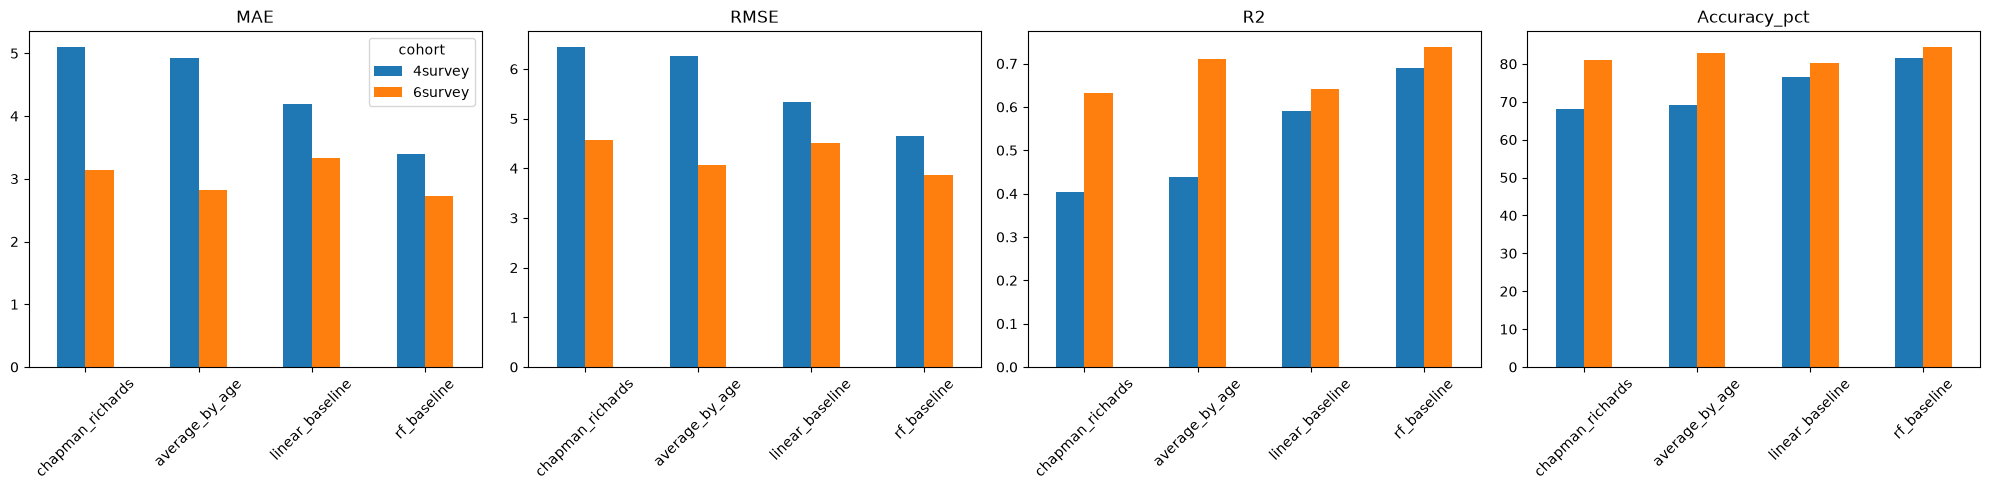

In [47]:
metrics_to_plot = ["MAE", "RMSE", "R2", "Accuracy_pct"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

for ax, metric_name in zip(axes, metrics_to_plot):
    pivoted = summary_df.pivot(index="model", columns="cohort", values=metric_name).loc[MODEL_NAMES]
    pivoted.plot(kind="bar", ax=ax, legend=(metric_name == metrics_to_plot[0]))
    ax.set_title(metric_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Caution on RF's strong numbers here.** Random forest currently looks like the best model across
both cohorts, but this evaluation is on `plot_level_split` — held-out plots still come from the
same forest, the same terrain distribution, and the same general neighbourhoods as training. The
prior dissertation this project extends (Lynch, 2025) found RF scored the highest accuracy in
exactly this kind of intra-distribution setup, but generalised very poorly once tested on
genuinely unseen plots. Their diagnosis: since RF still performed well on previously-seen-plot
temporal splits, the accuracy drop under spatial holdout wasn't caused by feature importance
shifting over time — it was that new plots introduced unseen feature combinations
(elevation/slope/wind exposure) that RF's tree-split structure has no way to interpolate between,
unlike a network learning a smooth function.

Lynch's broader case for a PINN over a plain DNN wasn't raw accuracy — it was **noise robustness**
(a PINN's accuracy degraded far more gradually than linear regression/DNN under added Gaussian
noise, since the physics term anchors predictions to a plausible growth shape) and
**redundant-feature tolerance** (deliberately redundant/noisy features hurt the linear model and
DNN, but the PINN maintained or improved performance — one "redundant" feature happened to align
with the Chapman-Richards equation's own time-dependence, giving the physics loss extra gradient
signal). They frame the physics term as a *soft* constraint — sufficient given the PINN only
models one aspect of forest growth, not the whole ecosystem, not a hard one.

**Implication for this project**: today's RF result is the easy half of the test, not a rebuttal
of the PINN case. **Section 10 below runs the harder test** (`spatial_block_split`, genuinely
unseen compartments) for all four baselines and shows RF losing its plot_level advantage there —
read that section before trusting the summary table above at face value.

## 6. Predicted vs. observed, residuals, and error-by-age — per model, per cohort

Using `models/common/plotting.py` directly (the same functions available to every model script),
not reimplemented here.

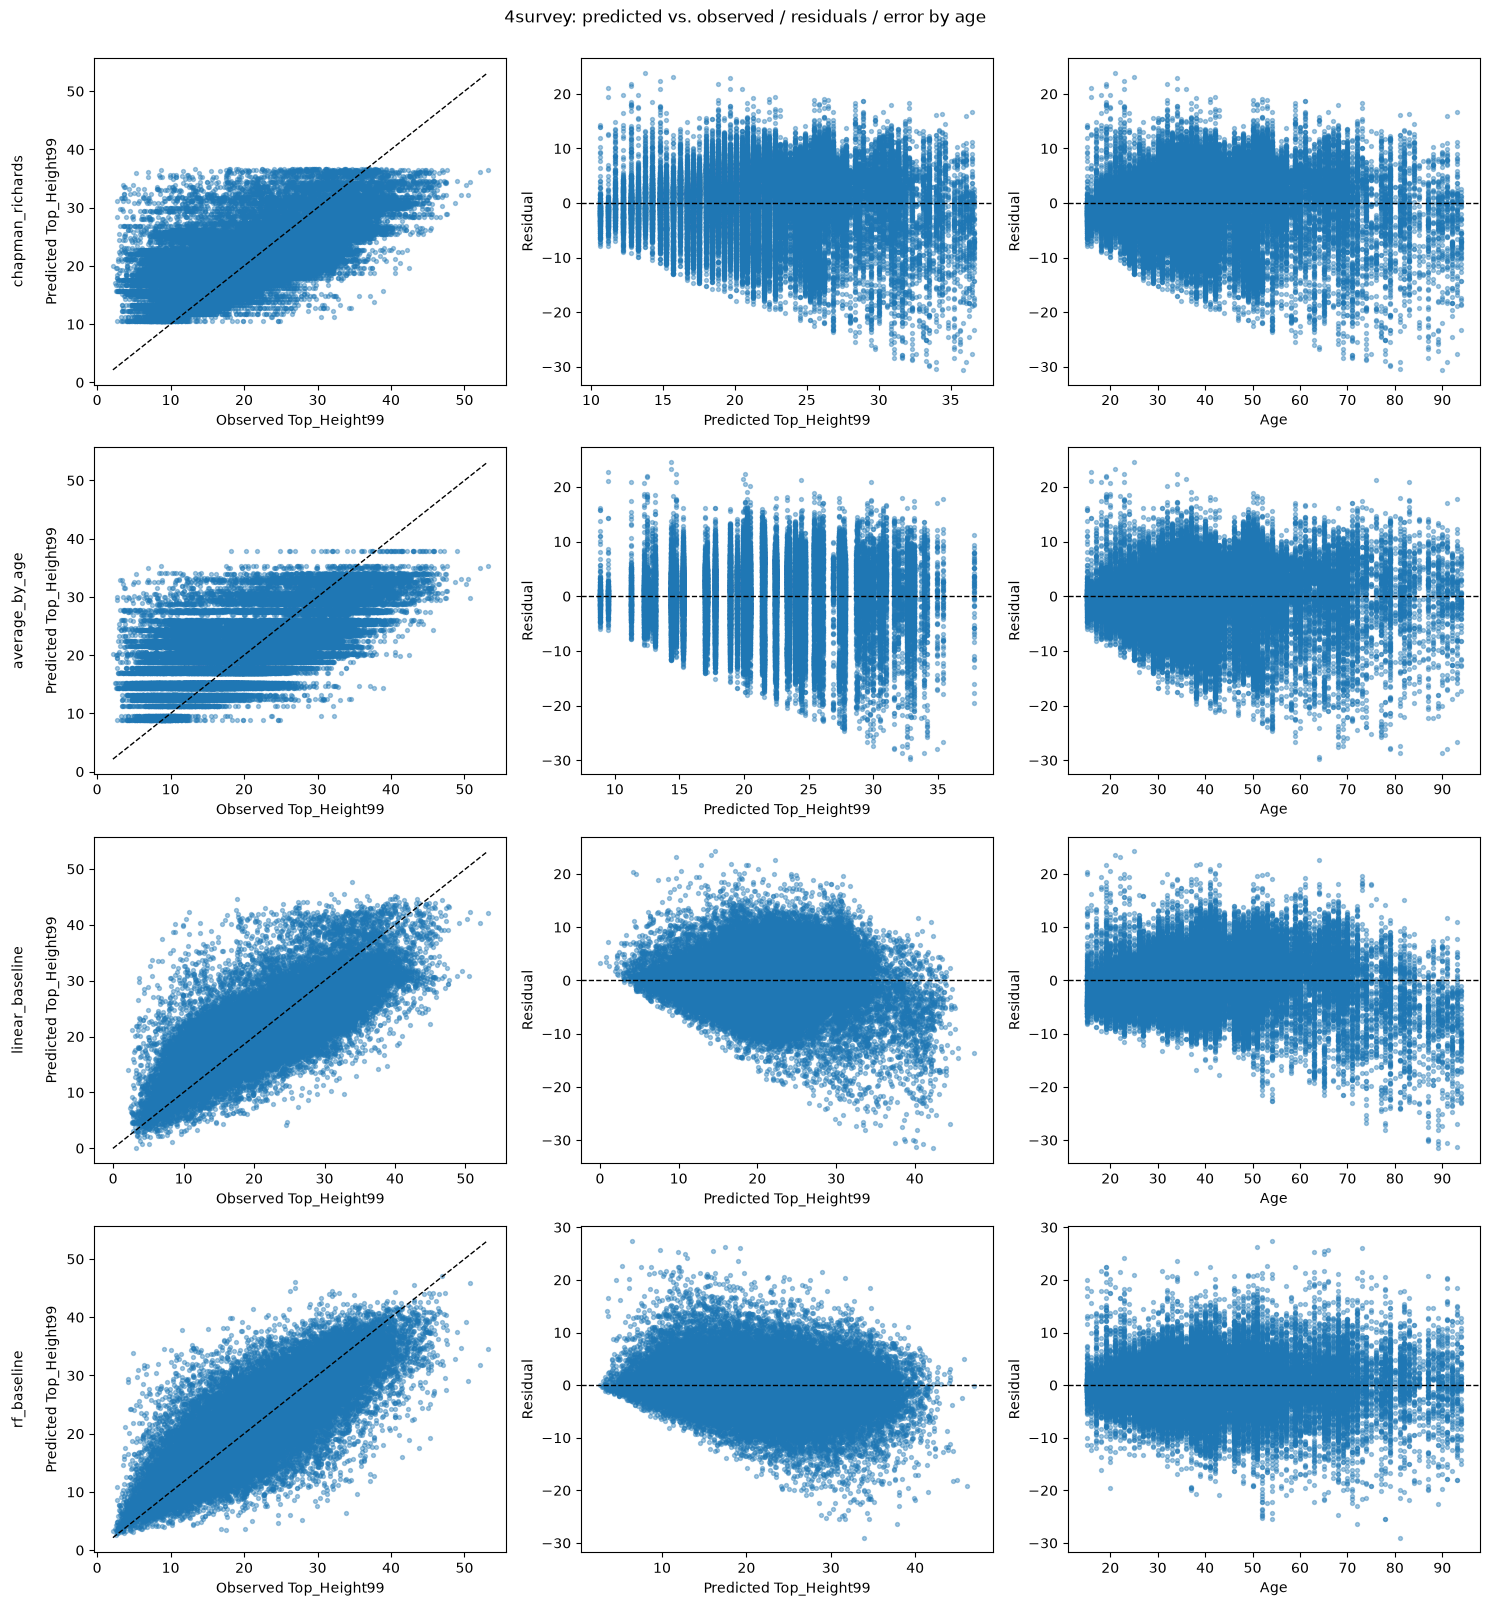

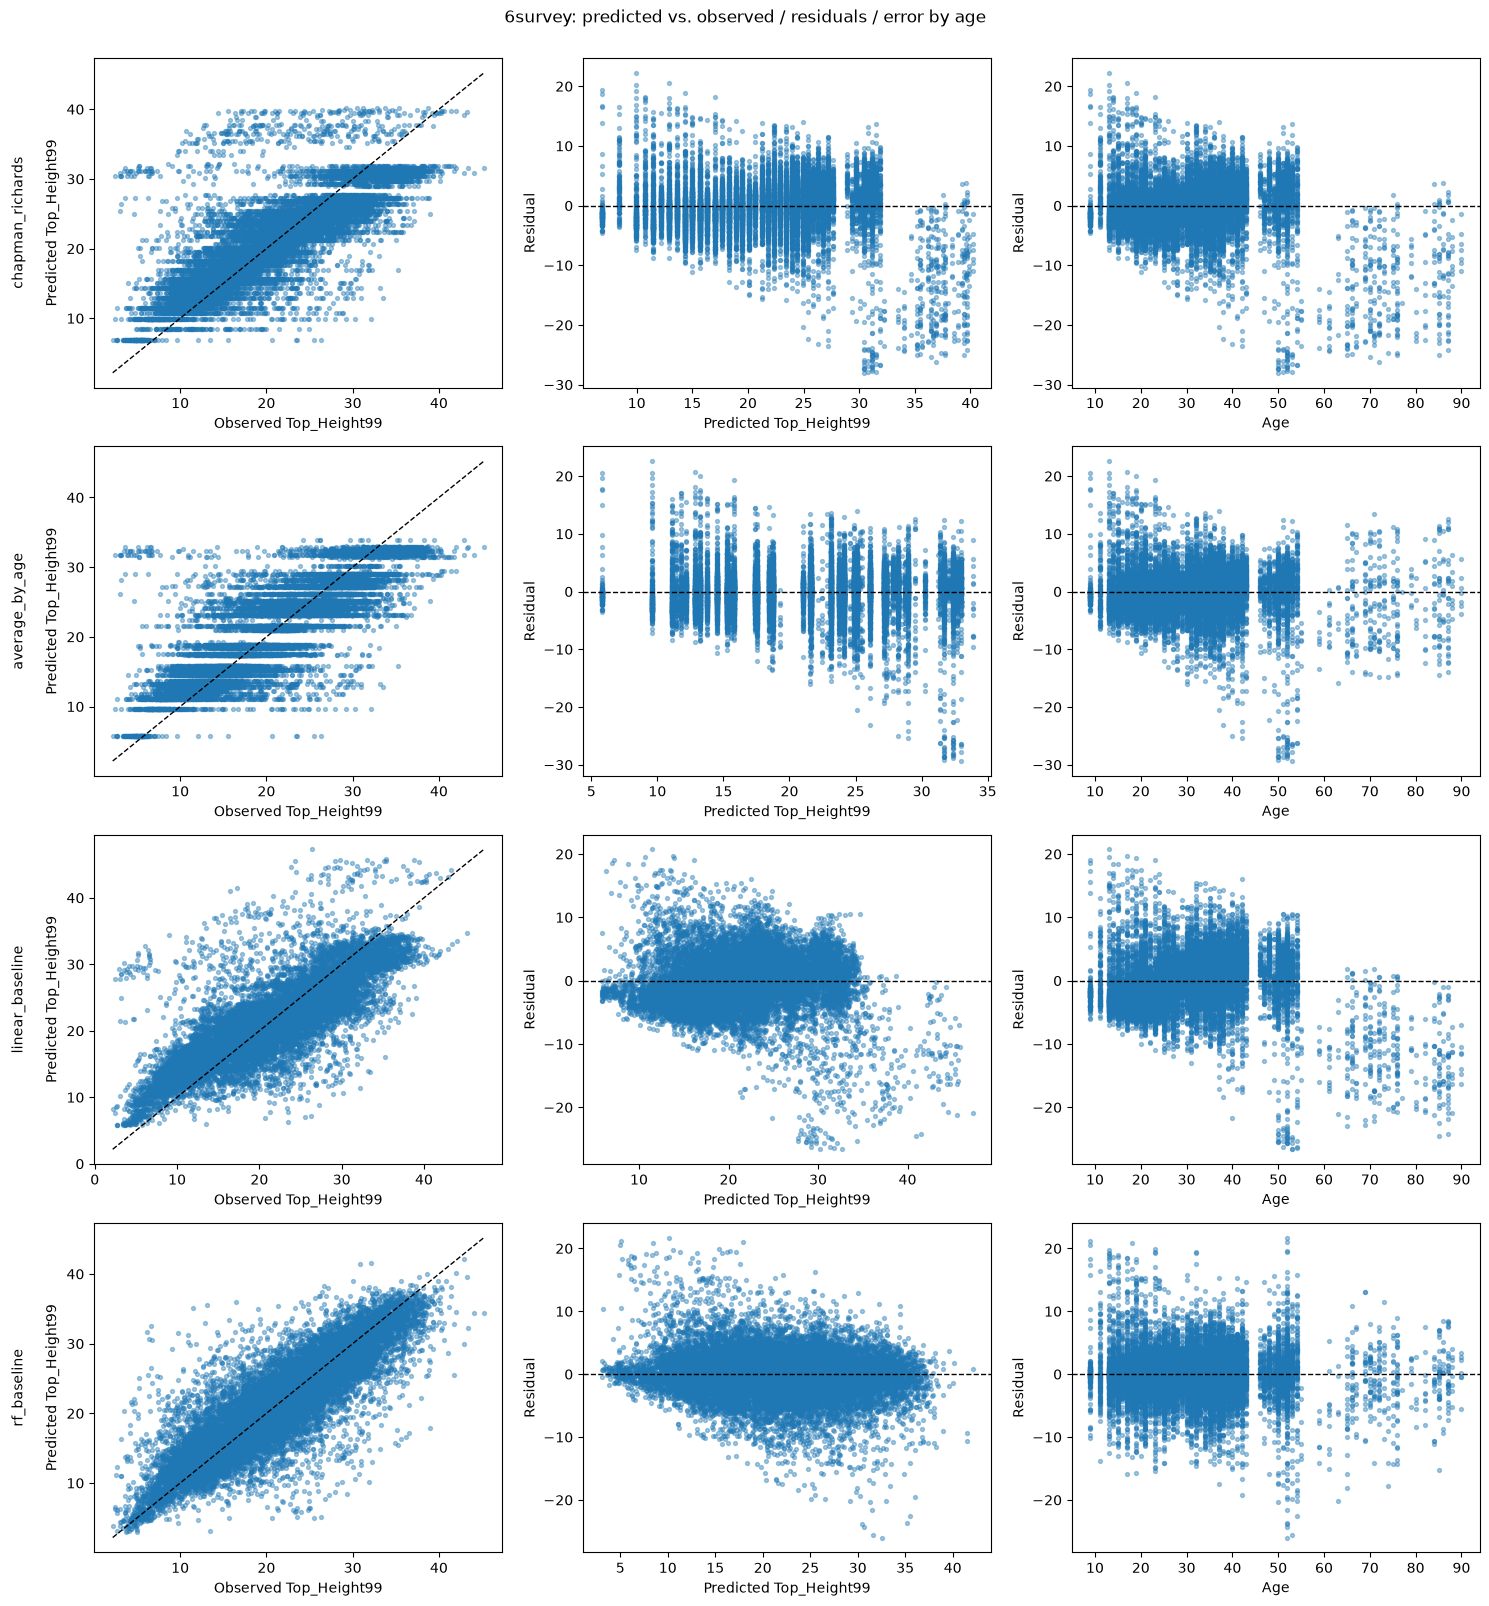

In [48]:
for cohort in COHORTS:
    fig, axes = plt.subplots(len(MODEL_NAMES), 3, figsize=(15, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"{cohort}: predicted vs. observed / residuals / error by age", y=1.001)

    for row, model_name in enumerate(MODEL_NAMES):
        predictions_df = all_predictions[(model_name, cohort)]
        observed = predictions_df["observed_top_height"]
        predicted = predictions_df["predicted_top_height"]
        age = predictions_df["Age"]

        plot_predicted_vs_observed(observed, predicted, ax=axes[row, 0])
        plot_residuals(observed, predicted, ax=axes[row, 1])
        plot_error_by_age(age, observed, predicted, ax=axes[row, 2])

        axes[row, 0].set_ylabel(f"{model_name}\n\nPredicted Top_Height99")

    plt.tight_layout()
    plt.show()

**How to read the plot**
- **Predicted vs observed (left)**: hugging the diagaonal = good fit, curvature away from the diagonal (falttening at high values) means cant predict true range(linear models reach a ceiling)
- **Residuals vs predicted (middle)**: should be random noise centered at 0 with no shape. If there is a shape, e.g. linear shoes arc, as it cannot bend to match the flattening curve.
- **Residual vs age (right)**: certain ages, the model breask down, e.g. linear and CR have negative residual for older ages, random forest neither over or under predicts


## 7. Age-banded breakdown

MRE inflates on short/young plots since it divides by observed height, so a global MRE can look
worse than a model's real fit quality on mature plots — the age-banded view (from
`models/common/metrics.py`) separates that out.

In [49]:
age_band_rows = []
for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        for band in all_metrics[(model_name, cohort)].get("age_bands", []):
            age_band_rows.append({
                "cohort": cohort,
                "model": model_name,
                "band": band["band"],
                "n_rows": band["n_rows"],
                "MAE": band["mae"],
                "RMSE": band["rmse"],
                "Bias": band["bias"],
                "MRE": band["mre"],
            })

age_band_df = pd.DataFrame(age_band_rows)
display(age_band_df.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "Bias": "{:.3f}", "MRE": "{:.3f}"}))

,cohort,model,band,n_rows,MAE,RMSE,Bias,MRE
0,4survey,chapman_richards,20-40,22709,4.391,5.486,-0.107,0.319
1,4survey,chapman_richards,40-60,16206,5.933,7.173,0.445,0.328
2,4survey,chapman_richards,60-80,4667,6.205,8.034,-0.268,0.310
3,4survey,chapman_richards,80+,1078,6.635,8.715,-3.260,0.300
4,4survey,average_by_age,20-40,22709,4.296,5.377,-0.006,0.308
5,4survey,average_by_age,40-60,16206,5.717,7.042,0.053,0.322
6,4survey,average_by_age,60-80,4667,5.910,7.616,-0.089,0.290
7,4survey,average_by_age,80+,1078,5.922,7.643,-0.261,0.252
8,4survey,linear_baseline,20-40,22709,3.415,4.277,-0.316,0.216
9,4survey,linear_baseline,40-60,16206,4.639,5.623,1.053,0.233


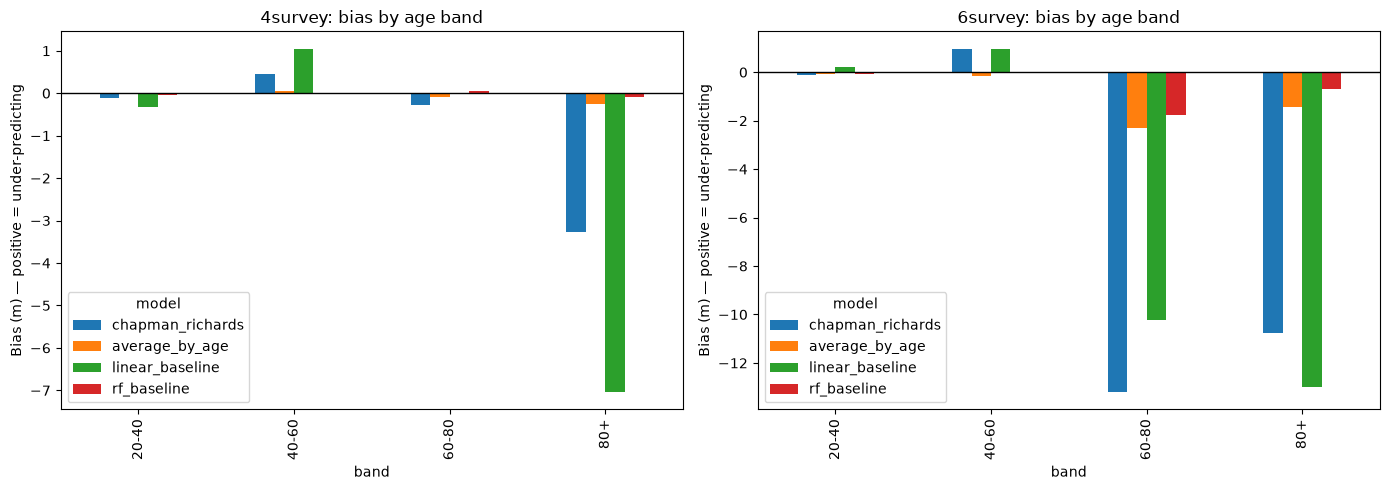

In [50]:
# Bias by age band is the clearest single view of where each model is
# systematically over- or under-predicting.
fig, axes = plt.subplots(1, len(COHORTS), figsize=(14, 5))

for ax, cohort in zip(axes, COHORTS):
    cohort_bands = age_band_df[age_band_df["cohort"] == cohort]
    pivoted = cohort_bands.pivot(index="band", columns="model", values="Bias")
    band_order = [b for b in ["20-40", "40-60", "60-80", "80+"] if b in pivoted.index]
    pivoted = pivoted.loc[band_order, MODEL_NAMES]

    pivoted.plot(kind="bar", ax=ax, color=[MODEL_COLORS[m] for m in MODEL_NAMES])
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{cohort}: bias by age band")
    ax.set_ylabel("Bias (m) — positive = under-predicting")

plt.tight_layout()
plt.show()

**Reading the age bands**: every band here clears the code's hard cutoff
(`MIN_ROWS_TO_TRUST_A_BAND = 30` in `evaluate_baselines.py`) — it has never actually fired for
these results, since even the smallest band (6survey's `80+`) has 110 rows. But clearing that
cutoff doesn't mean every band is equally trustworthy. Sample size still matters for how much a
band's number should be trusted: 4survey's `20-40` band has 22,709 rows vs. `80+`'s 1,078 — about
20x fewer — so by standard-error scaling (`~1/sqrt(n)`), the `80+` band's MAE/Bias is roughly
`sqrt(22709/1078) ~ 4.6x` noisier, purely from sample size, even though both technically clear the
30-row bar. It's sharpest in 6survey's `80+` band (110 rows), where a single unusual plot can swing
the reported Bias far more than the same plot would in `20-40`. Rule of thumb: treat `20-40` and
`40-60` as solid, `60-80` as reasonably trustworthy, and `80+` (especially in 6survey) as
indicative rather than precise — don't conclude a model is "bad at 80+" from one Bias value there
without checking it isn't driven by a handful of plots.

## 8. Chapman-Richards fitted parameters vs. prior dissertation

The only model here with directly interpretable, checkable fitted parameters.

In [51]:
PRIOR_CR_PARAMS = {"y_max": 46.1126, "k": 0.01866979, "p": 1.0175}

cr_param_rows = [{"cohort": "prior (Lynch, 2025)", **PRIOR_CR_PARAMS}]
for cohort in COHORTS:
    params_path = project_root / "outputs" / "chapman_richards" / cohort / "params.json"
    with open(params_path) as f:
        params = json.load(f)
    cr_param_rows.append({"cohort": cohort, "y_max": params["y_max"], "k": params["k"], "p": params["p"]})

cr_param_df = pd.DataFrame(cr_param_rows)
display(cr_param_df.style.format({"y_max": "{:.6f}", "k": "{:.8f}", "p": "{:.6f}"}))

,cohort,y_max,k,p
0,"prior (Lynch, 2025)",46.112600,0.01866979,1.017500
1,4survey,53.490917,0.01099022,0.858848
2,6survey,46.513191,0.02373657,1.162634


## 9. Growth curves and residuals across survey years

Every baseline here is fit **once**, on the whole pooled training set across all survey years at
once (a single `curve_fit`/`LinearRegression().fit()` call, not one fit per plot then adjusted) —
see `models/chapman_richards/chapman_richards.py` and `models/linear_baseline/linear_baseline.py`.
That means each model produces exactly one Age -> Height relationship per cohort, applied
identically whether a row came from the 2008 survey or the 2023 survey.

But the same age band is measurably taller in later surveys (e.g. 4survey age-30 plots average
~16m in 2008 vs. ~22m in 2023 — site improvement, climate, or survey-era measurement differences,
not noise: cell sizes are in the thousands). A single pooled curve cannot bend to fit both eras at
once, so it settles somewhere in between and is systematically biased for the years at the
extremes.

The left panel below overlays each model's predicted points (black) on the observed points,
coloured by survey year — if a colour sits mostly above or below the black points at a given age,
that survey year is where the pooled fit is biased. The right panel is the same effect as a number:
mean bias (observed - predicted) per survey year.

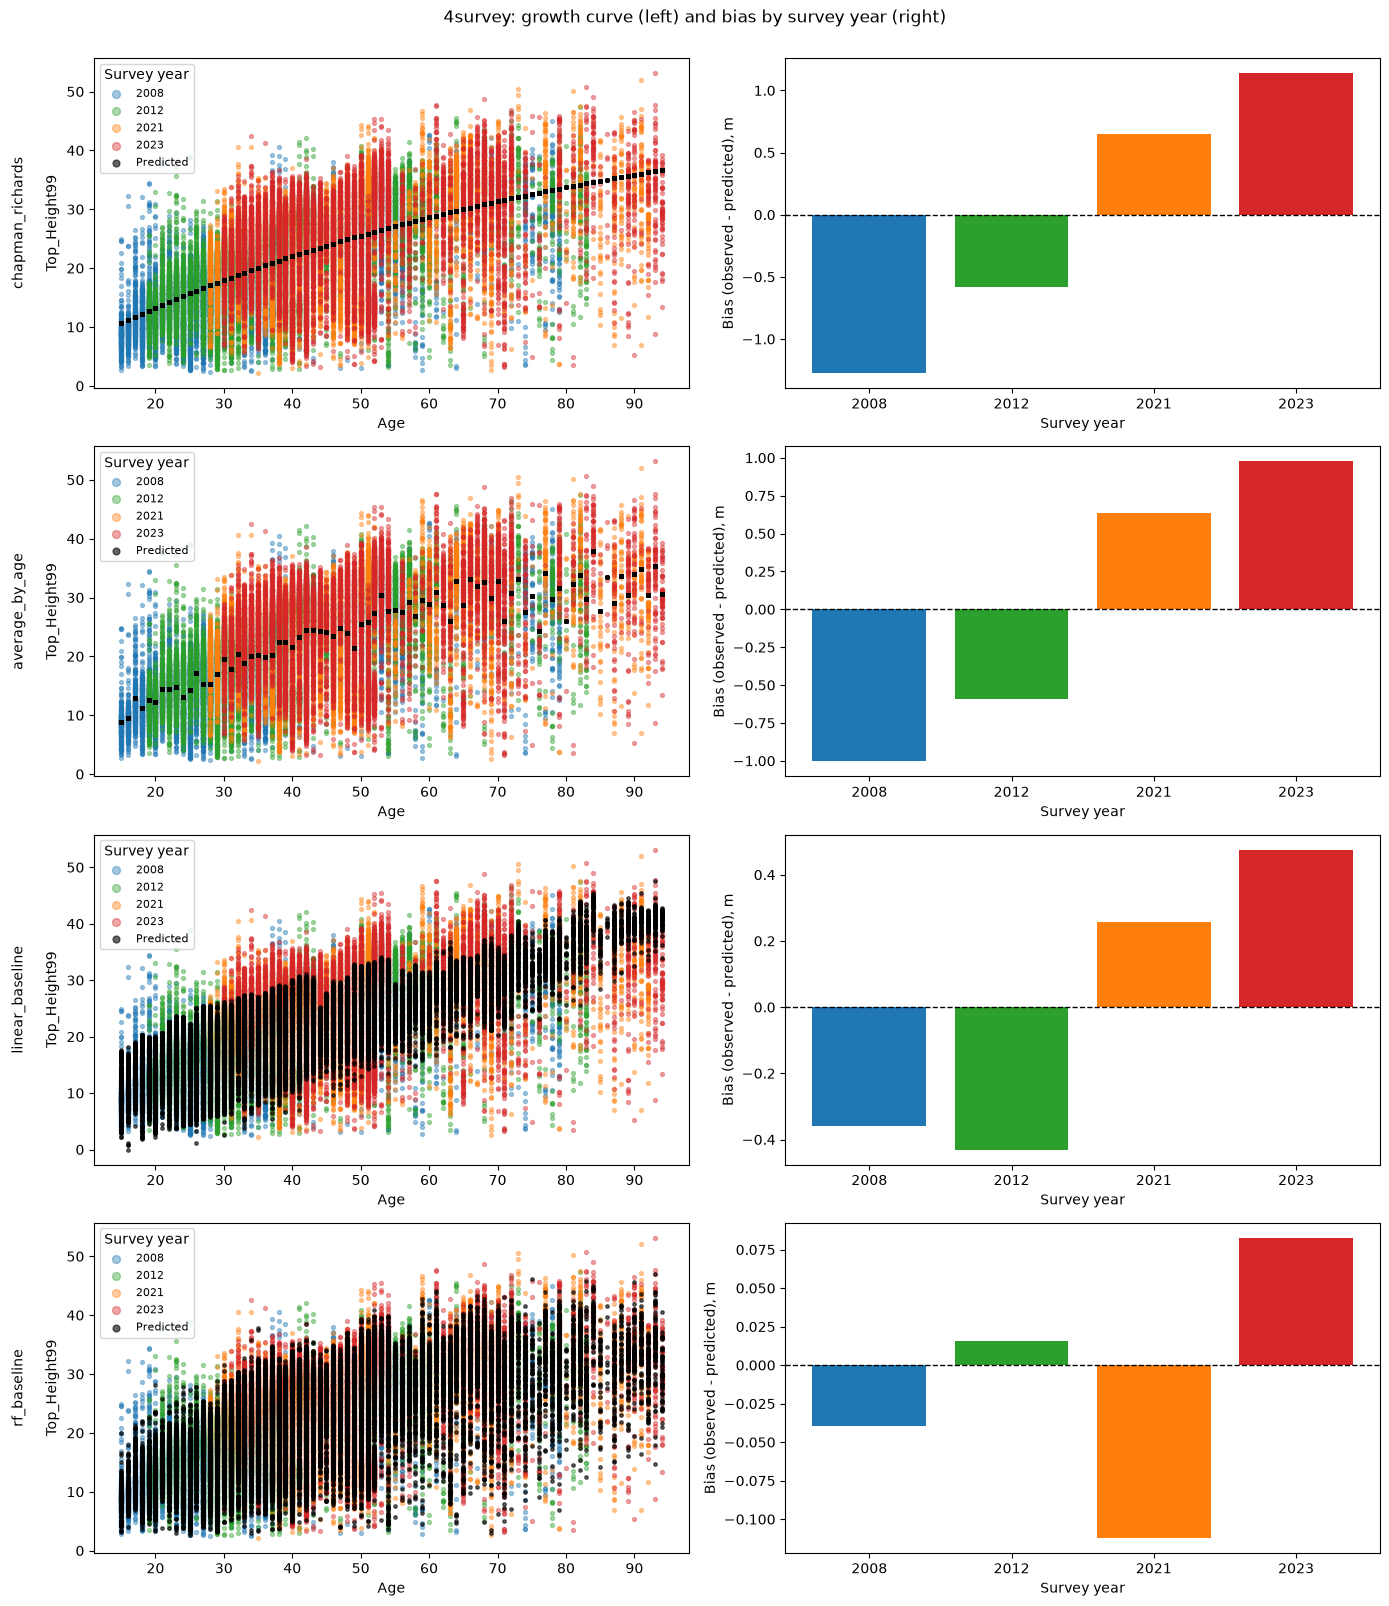

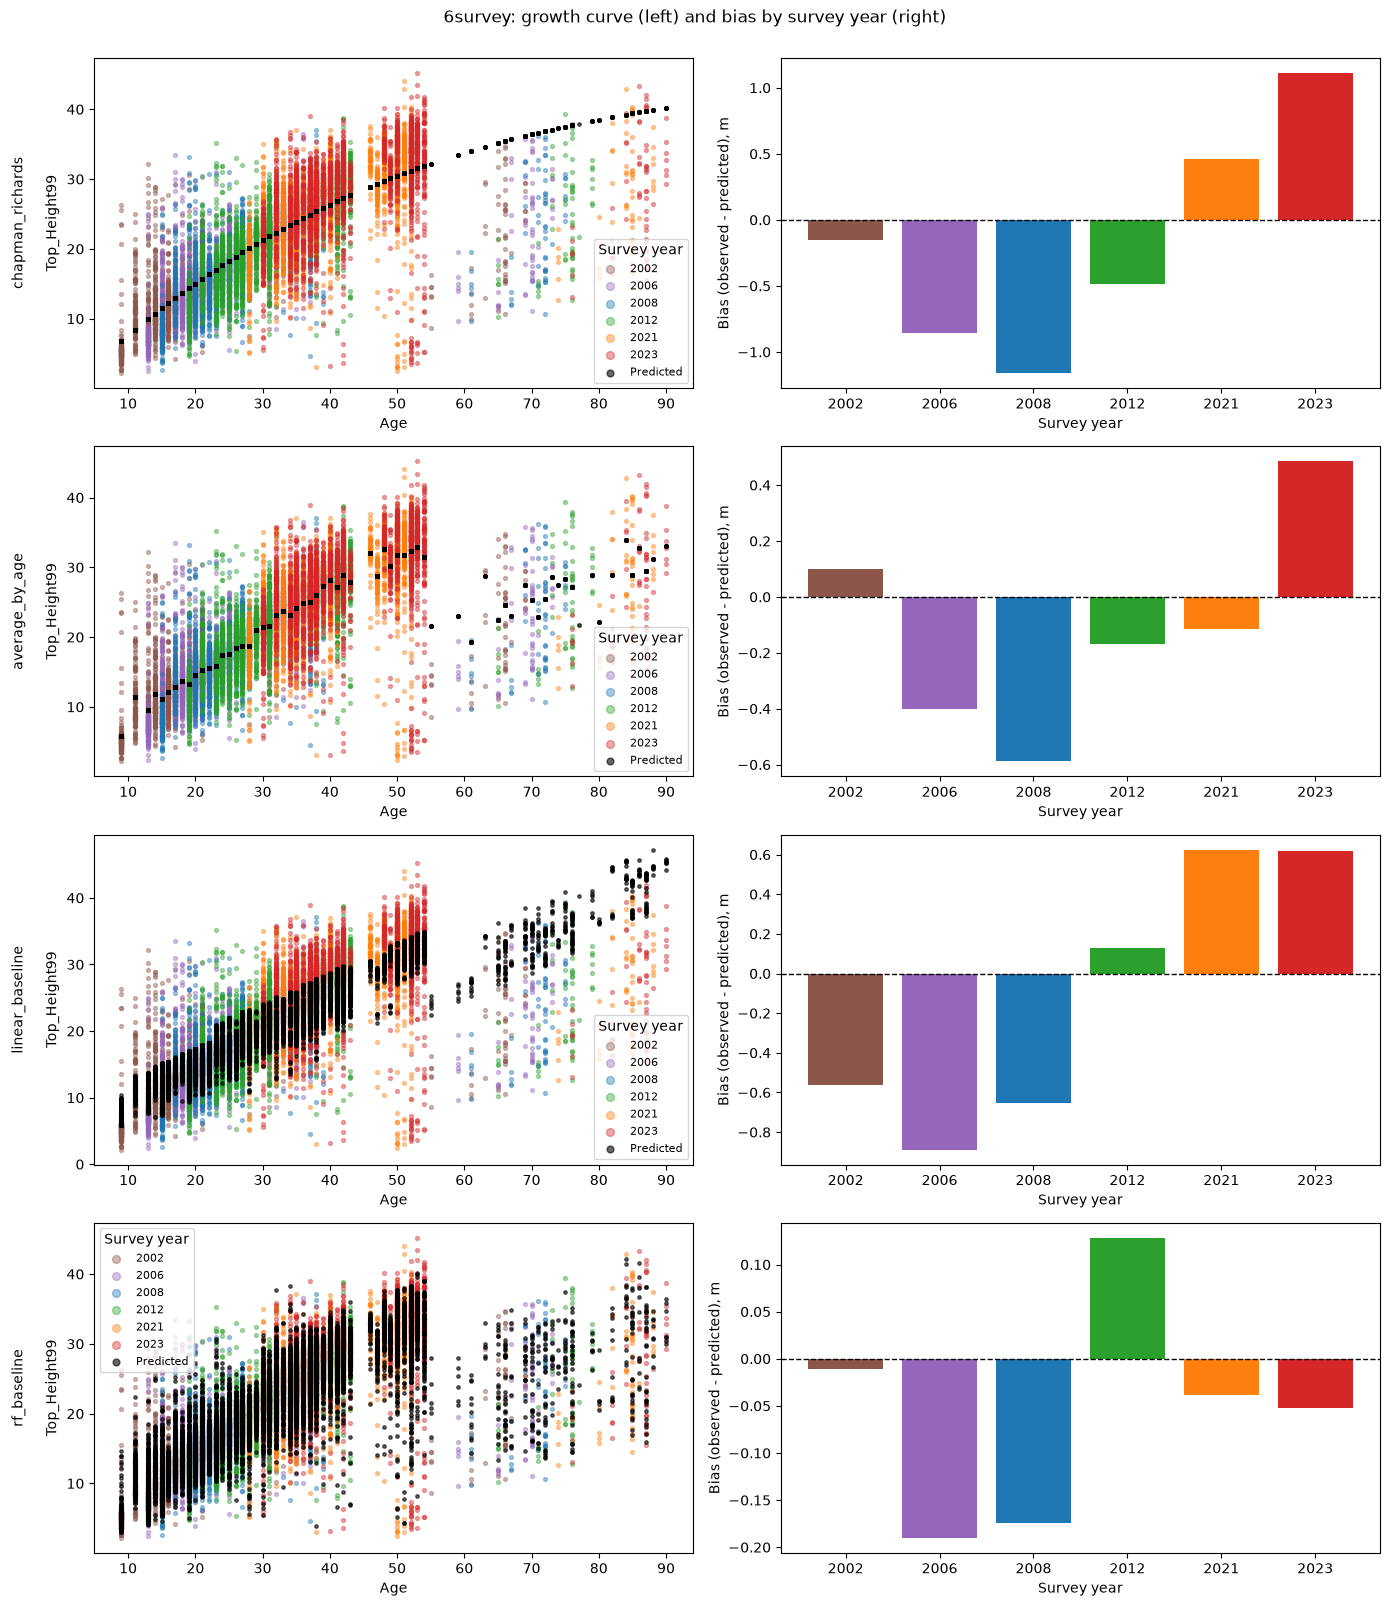

In [52]:
for cohort in COHORTS:
    fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(14, 4 * len(MODEL_NAMES)))
    fig.suptitle(f"{cohort}: growth curve (left) and bias by survey year (right)", y=1.001)

    for row, model_name in enumerate(MODEL_NAMES):
        predictions_df = all_predictions[(model_name, cohort)]
        observed = predictions_df["observed_top_height"]
        predicted = predictions_df["predicted_top_height"]
        age = predictions_df["Age"]
        lidar_year = predictions_df["LiDAR_year"]

        plot_growth_curve(age, observed, predicted, lidar_year, ax=axes[row, 0])
        plot_bias_by_year(lidar_year, observed, predicted, ax=axes[row, 1])

        axes[row, 0].set_ylabel(f"{model_name}\n\nTop_Height99")

    plt.tight_layout()
    plt.show()

**Growth curve + bias-by-year** 
- Isolates how much of the residual is a survey-era effect rather than random noise. Right now, every baseline is Age-only, so this plot's colored-year pattern is essentially showing you the ceiling on what an Age-only model can ever achieve — Chapman-Richards and PINN-age-only will show the same year-bias pattern, since neither sees anything that could distinguish 2008 from 2023.
- Re-run this exact plot on PINN-age-only's residuals and PINN-with-environment's residuals.
- If environmental variables are doing real work, the colored points should collapse onto the black line and the bias-by-year bars should shrink toward zero specifically in the environment version. That shrinkage is your result.

### 9a. How big is the year effect, in metres? (diagnostic only)

The plot above shows the survey-year confound *qualitatively*. This puts a number on it:
`models/chapman_richards/year_effect_diagnostic.py` fits Chapman-Richards with an extra additive
offset on `y_max` per survey year (earliest year = reference, `delta = 0`), on the exact same
training rows the plain age-only Chapman-Richards baseline used.

**This model must never be compared against the other baselines or entered into the summary
tables above.** A year delta only exists for the specific calendar years in this training data —
it has no predictive value for a plot surveyed in a year outside 2002-2023, unlike a real
environmental covariate. Its only purpose is to answer "how many metres of the residual is a
systematic year shift, and how much of the total squared error does that account for" — a
concrete target to check PINN-with-environment against later: if environmental variables are
doing the same job as this diagnostic's year deltas, PINN-environment's improvement over
PINN-age-only should land in a similar range.

Run `python -m models.chapman_richards.run_year_effect_diagnostic` to regenerate.

cohort,4survey,6survey
year,,
2002,+nan,+0.000
2006,+nan,-2.306
2008,+0.000,-2.580
2012,+2.189,-0.422
2021,+5.703,+2.322
2023,+6.864,+3.582


,cohort,reference_year,plain_cr_sse,year_effect_sse,pct_squared_error_explained_by_year
0,4survey,2008,"5,900,328","5,779,041",2.06%
1,6survey,2002,"948,447","903,446",4.74%


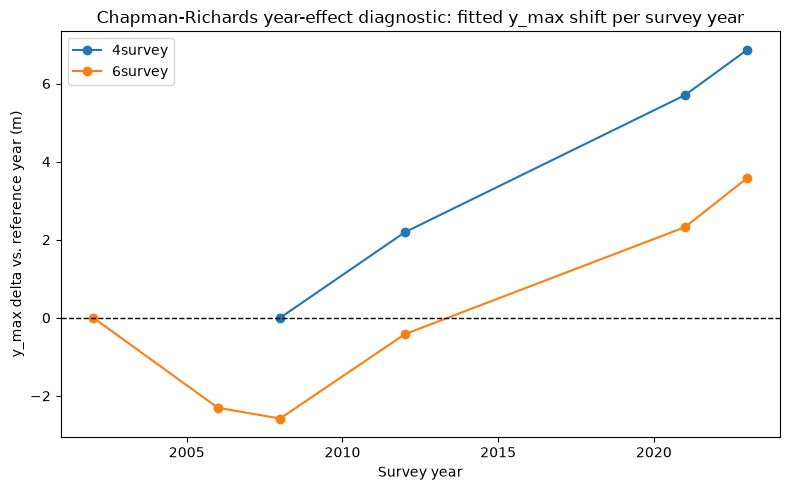

In [53]:
year_diagnostic_rows = []
year_delta_rows = []

for cohort in COHORTS:
    diagnostic_path = project_root / "outputs" / "chapman_richards_year_diagnostic" / cohort / "params.json"
    with open(diagnostic_path) as f:
        diagnostic = json.load(f)

    for year, delta in diagnostic["year_deltas"].items():
        year_delta_rows.append({"cohort": cohort, "year": int(year), "y_max_delta": delta})

    year_diagnostic_rows.append({
        "cohort": cohort,
        "reference_year": diagnostic["reference_year"],
        "plain_cr_sse": diagnostic["plain_cr_sum_squared_error"],
        "year_effect_sse": diagnostic["sum_squared_error"],
        "pct_squared_error_explained_by_year": diagnostic["variance_explained_by_year_pct"],
    })

year_delta_df = pd.DataFrame(year_delta_rows)
year_diagnostic_df = pd.DataFrame(year_diagnostic_rows)

display(year_delta_df.pivot(index="year", columns="cohort", values="y_max_delta").style.format("{:+.3f}"))
display(year_diagnostic_df.style.format({
    "plain_cr_sse": "{:,.0f}", "year_effect_sse": "{:,.0f}", "pct_squared_error_explained_by_year": "{:.2f}%",
}))

fig, ax = plt.subplots(figsize=(8, 5))
for cohort in COHORTS:
    cohort_deltas = year_delta_df[year_delta_df["cohort"] == cohort].sort_values("year")
    ax.plot(cohort_deltas["year"], cohort_deltas["y_max_delta"], marker="o", label=cohort)

ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Survey year")
ax.set_ylabel("y_max delta vs. reference year (m)")
ax.set_title("Chapman-Richards year-effect diagnostic: fitted y_max shift per survey year")
ax.legend()
plt.tight_layout()
plt.show()

**In plain terms**: trees of the same age are taller in later surveys than earlier ones — up to
7m taller comparing 2008 to 2023 in 4survey. That's real, not noise. But when we ask "how much of
the model's total prediction error does this year gap explain," the answer is only **2.06% in
4survey and 4.74% in 6survey**. So the year effect is real but small — it is not the main reason
these models get predictions wrong. Most of the error is coming from something else the diagnostic
doesn't measure (e.g. some plots just naturally grow better than others regardless of year, or
plain measurement noise).

**Why this matters for the PINN**: if adding environmental data to the PINN only fixes this year
issue, error should only drop by about 2-5%. If it drops by a lot more than that, the
environmental data is fixing something bigger than the year problem — most likely telling apart
good growing sites from bad ones. So a big improvement from PINN-with-environment shouldn't
automatically be credited to "fixed the year confound" — it's probably doing something else
useful, and that's worth pinning down explicitly.

## 10. Generalization tests: spatial_block_split and temporal_split vs. plot_level_split

Section 5's caution note above promised this test. `plot_level_split` (used everywhere above)
shuffles individual plots into train/val/test at random, so a test plot usually sits right next to
a training plot. This section runs the same four baselines under two harder conditions instead:

- **`spatial_block_split`**: whole forestry compartments (`cpmt`, 296 of them) go to train/val/test
  together, with a 60m buffer removing any training plot too close to a held-out plot (matching
  the buffer distance already validated in
  `data_exploration_gpkg/notebooks/spatial_temporal_split_visualisation.ipynb`). A test plot's
  nearest training neighbour can now be kilometres away. Tests: does the model generalise to
  unseen *places*?
- **`temporal_split`**: train on 2008+2012 (4survey) / 2002-2012 (6survey), validate on 2021, test
  on 2023 (`TEMPORAL_YEARS` in `models/common/splits.py`). The same plot legitimately appears in
  both train and test rows here — that's expected, not a leak, since this tests something
  different: does the model generalise to unseen *time*, i.e. predict a real future survey it
  never trained on?

**Scope caveat**: none of these four baselines have any terrain/environmental features yet (RF's
inputs are `Age, CanopyCover, Thin, time_since_thinning, time_since_thinning_missing,
recent_thinning_5yr, yldc`). So `spatial_block_split` tests whether RF overfits to *whatever*
varies compartment-to-compartment in this feature set, not specifically Lynch's
terrain-interpolation mechanism (elevation/slope/wind) — that needs terrain features added first.
Neither split says anything about PINN vs. RF yet, since PINN doesn't exist yet.

To regenerate the results read below:
```
python -m models.baselines.run_baselines --split-type spatial_block
python -m models.baselines.evaluate_baselines --split-type spatial_block
python -m models.baselines.run_baselines --split-type temporal
python -m models.baselines.evaluate_baselines --split-type temporal
```

In [54]:
SPLIT_TYPES = ["plot_level", "spatial_block", "temporal"]


def outputs_dir(*parts, split_type):
    # Mirrors output_dir() in models/baselines/run_baselines.py: plot_level
    # results live directly under outputs/, spatial_block and temporal
    # results live under outputs/spatial_block/ and outputs/temporal/, so no
    # split type ever collides with another.
    if split_type in ("spatial_block", "temporal"):
        return project_root / "outputs" / split_type / Path(*parts)
    return project_root / "outputs" / Path(*parts)


def load_metrics_for_split(model_name, cohort, split_type):
    path = outputs_dir(model_name, cohort, "metrics.json", split_type=split_type)
    with open(path) as f:
        return json.load(f)


# Kept separate from all_metrics above (which is plot_level only, keyed by
# (model_name, cohort)) rather than overwriting it, since sections 1-7 above
# still rely on that dict's original two-part key.
generalization_metrics = {}
for split_type in SPLIT_TYPES:
    for cohort in COHORTS:
        for model_name in MODEL_NAMES:
            generalization_metrics[(model_name, cohort, split_type)] = load_metrics_for_split(
                model_name, cohort, split_type
            )

print(f"Loaded metrics for {len(MODEL_NAMES)} models x {len(COHORTS)} cohorts x {len(SPLIT_TYPES)} split types")

Loaded metrics for 4 models x 2 cohorts x 3 split types


### 10.1 Does test-split error get worse under the harder splits, and for which models?

`pct_change` is `(harder_split - plot_level) / plot_level * 100` — positive means the model got
*worse* than its easy-split baseline. This is the direct test of Lynch's claim for
`spatial_block`: if RF is disproportionately worse there while the other three baselines are flat
or improve, that replicates their finding, even without terrain features. `temporal` asks a
different question (unseen time, not unseen place) and is shown alongside for comparison, not as
a second version of the same test.

In [55]:
comparison_rows = []
for cohort in COHORTS:
    for model_name in MODEL_NAMES:
        plot_m = generalization_metrics[(model_name, cohort, "plot_level")]
        spatial_m = generalization_metrics[(model_name, cohort, "spatial_block")]
        temporal_m = generalization_metrics[(model_name, cohort, "temporal")]
        comparison_rows.append({
            "cohort": cohort,
            "model": model_name,
            "plot_level_RMSE": plot_m["rmse"],
            "spatial_block_RMSE": spatial_m["rmse"],
            "spatial_pct_change": (spatial_m["rmse"] - plot_m["rmse"]) / plot_m["rmse"] * 100,
            "temporal_RMSE": temporal_m["rmse"],
            "temporal_pct_change": (temporal_m["rmse"] - plot_m["rmse"]) / plot_m["rmse"] * 100,
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.style.format({
    "plot_level_RMSE": "{:.3f}", "spatial_block_RMSE": "{:.3f}", "spatial_pct_change": "{:+.1f}%",
    "temporal_RMSE": "{:.3f}", "temporal_pct_change": "{:+.1f}%",
}).background_gradient(subset=["spatial_pct_change", "temporal_pct_change"], cmap="RdYlGn_r", vmin=-15, vmax=140))

,cohort,model,plot_level_RMSE,spatial_block_RMSE,spatial_pct_change,temporal_RMSE,temporal_pct_change
0,4survey,chapman_richards,6.441,6.107,-5.2%,7.614,+18.2%
1,4survey,average_by_age,6.259,6.348,+1.4%,8.810,+40.8%
2,4survey,linear_baseline,5.338,5.817,+9.0%,6.347,+18.9%
3,4survey,rf_baseline,4.653,5.988,+28.7%,7.807,+67.8%
4,6survey,chapman_richards,4.568,3.967,-13.2%,5.748,+25.8%
5,6survey,average_by_age,4.060,3.892,-4.1%,9.810,+141.7%
6,6survey,linear_baseline,4.514,4.086,-9.5%,6.940,+53.7%
7,6survey,rf_baseline,3.855,4.604,+19.4%,5.349,+38.8%


In [56]:
# Rank matters as much as pct_change: pct_change shows how far a model fell
# from where it started, but says nothing about whether it's still the best
# or worst model on the harder split. Both views are needed together.
for cohort in COHORTS:
    for split_type, rmse_col in [("spatial_block", "spatial_block_RMSE"), ("temporal", "temporal_RMSE")]:
        print(f"{cohort} -- {split_type} test-split RMSE, ranked best to worst:")
        cohort_rows = comparison_df[comparison_df["cohort"] == cohort].sort_values(rmse_col)
        for rank, row in enumerate(cohort_rows.itertuples(), start=1):
            print(f"  {rank}. {row.model:<20} RMSE={getattr(row, rmse_col):.3f}")
        print()

4survey -- spatial_block test-split RMSE, ranked best to worst:
  1. linear_baseline      RMSE=5.817
  2. rf_baseline          RMSE=5.988
  3. chapman_richards     RMSE=6.107
  4. average_by_age       RMSE=6.348

4survey -- temporal test-split RMSE, ranked best to worst:
  1. linear_baseline      RMSE=6.347
  2. chapman_richards     RMSE=7.614
  3. rf_baseline          RMSE=7.807
  4. average_by_age       RMSE=8.810

6survey -- spatial_block test-split RMSE, ranked best to worst:
  1. average_by_age       RMSE=3.892
  2. chapman_richards     RMSE=3.967
  3. linear_baseline      RMSE=4.086
  4. rf_baseline          RMSE=4.604

6survey -- temporal test-split RMSE, ranked best to worst:
  1. rf_baseline          RMSE=5.349
  2. chapman_richards     RMSE=5.748
  3. linear_baseline      RMSE=6.940
  4. average_by_age       RMSE=9.810



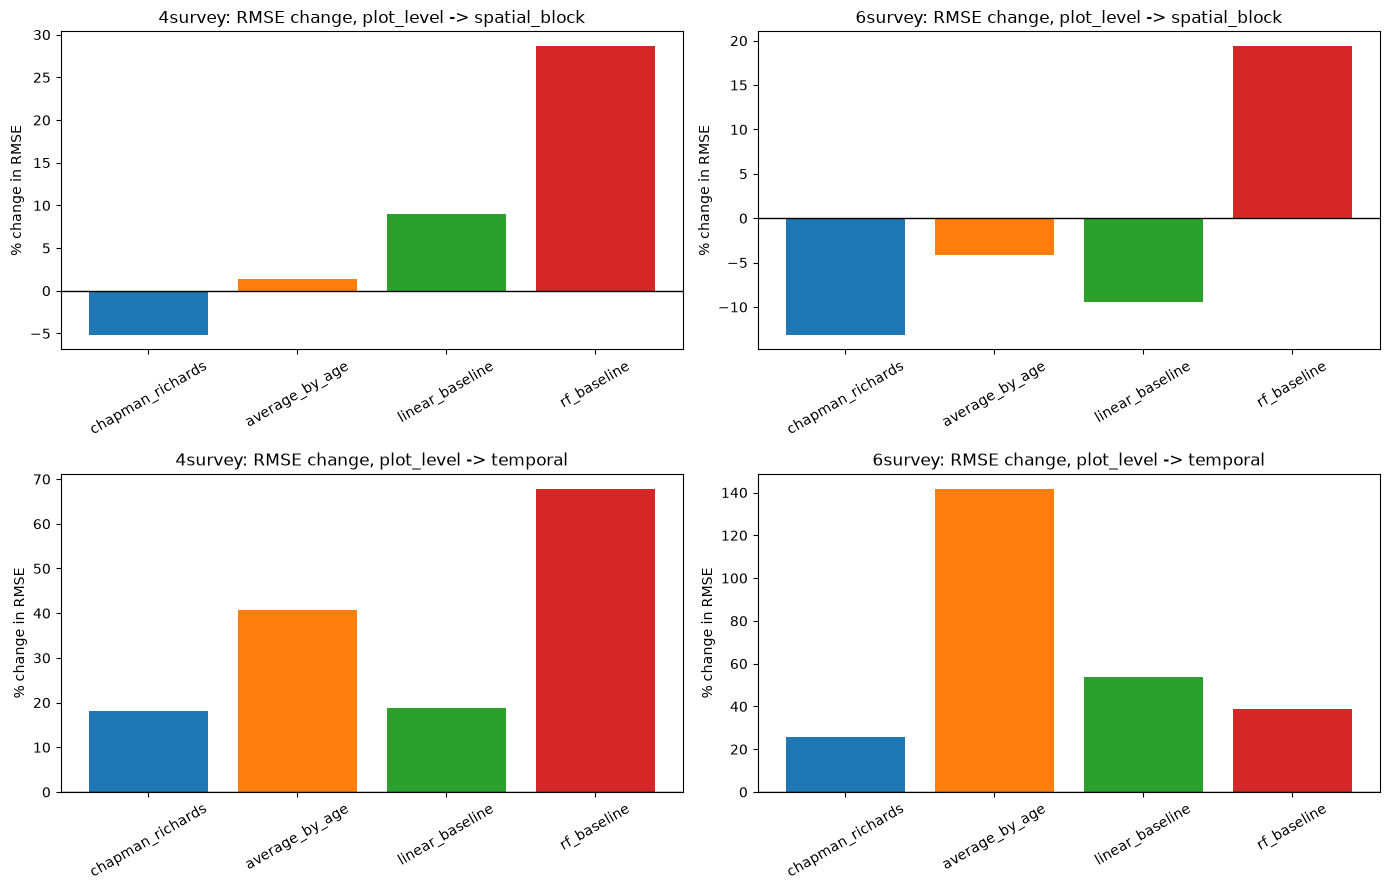

In [57]:
# spatial_block and temporal changes are on very different scales (single
# digits vs. up to +140%), so each gets its own row with its own y-axis --
# a shared axis would squash the spatial bars to invisibility next to the
# temporal ones.
fig, axes = plt.subplots(2, len(COHORTS), figsize=(14, 9))

for col, cohort in enumerate(COHORTS):
    cohort_rows = comparison_df[comparison_df["cohort"] == cohort].set_index("model").loc[MODEL_NAMES]

    ax_spatial = axes[0, col]
    ax_spatial.bar(cohort_rows.index, cohort_rows["spatial_pct_change"], color=[MODEL_COLORS[m] for m in MODEL_NAMES])
    ax_spatial.axhline(0, color="black", linewidth=1)
    ax_spatial.set_title(f"{cohort}: RMSE change, plot_level -> spatial_block")
    ax_spatial.set_ylabel("% change in RMSE")
    ax_spatial.tick_params(axis="x", rotation=30)

    ax_temporal = axes[1, col]
    ax_temporal.bar(cohort_rows.index, cohort_rows["temporal_pct_change"], color=[MODEL_COLORS[m] for m in MODEL_NAMES])
    ax_temporal.axhline(0, color="black", linewidth=1)
    ax_temporal.set_title(f"{cohort}: RMSE change, plot_level -> temporal")
    ax_temporal.set_ylabel("% change in RMSE")
    ax_temporal.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Spatial generalization — rank and pct_change tell different parts of the story, don't conflate
them**:

- **Rank on the spatial_block test split**: RF is the outright worst of the four models in
  6survey (RMSE 4.604, highest). In 4survey it is actually 2nd best (5.988), behind linear
  regression (5.817) — *not* the worst there. So "RF is the worst model" is only literally true in
  one of the two cohorts.
- **pct_change from plot_level to spatial_block**: RF has the largest degradation in *both*
  cohorts — RMSE up 28.7% (4survey) and 19.4% (6survey) — while Chapman-Richards and average-by-age
  stay flat or improve, and linear regression is mixed (worse in 4survey, better in 6survey).

The precise, defensible claim: **RF loses its plot_level advantage faster than the other three
baselines when tested on genuinely unseen compartments.** That's a real, if partial, replication of
Lynch's finding — but "RF is worse overall" is not quite right; "RF's plot_level advantage is not
robust to spatial holdout" is the accurate version. It does **not** yet prove Lynch's specific
*terrain-interpolation* mechanism (no elevation/slope/wind features exist yet), and says nothing
about PINN vs. RF, since PINN doesn't exist yet.

**Temporal generalization — a much bigger effect, and it inverts the ranking.** Every model
degrades far more under `temporal` than under `spatial_block` — by an order of magnitude in some
cases. Two things stand out:

1. **The scale is dramatically larger.** 6survey's `average_by_age` RMSE degrades by **+141.7%**
   under `temporal` vs. only -4.1% (an *improvement*) under `spatial_block` — this is the model
   whose R² went negative on the temporal test split (section above), meaning it's worse than
   just predicting the mean height. `linear_baseline` isn't far behind at +53.7%. Predicting 11
   years into the future (2012 → 2023) is a fundamentally harder ask than predicting a
   never-visited compartment in a year the model has already seen data from.
2. **RF is comparatively more temporal-robust than it is spatial-robust.** RF's degradation under
   `temporal` (+67.8% in 4survey, +38.8% in 6survey) is large in absolute terms, but it is *not*
   the worst-degrading model under `temporal` the way it was under `spatial_block` — `average_by_age`
   and `linear_baseline` both degrade more. Plausible reason: a lookup table
   (`average_by_age`) and a straight line (`linear_baseline`) have no mechanism at all for
   extrapolating to ages/conditions outside their training range, whereas RF's tree splits and
   Chapman-Richards' smooth analytic curve both have *some* extrapolation behaviour, however
   imperfect.

**Chapman-Richards is the most temporally robust model in relative terms** (+18.2%/+25.8%, the
smallest degradation of the four under `temporal` in both cohorts) despite being the simplest —
its single smooth sigmoid, constrained to approach one asymptote, apparently extrapolates to a
future survey more gracefully than a lookup table, a straight line, or an unconstrained tree
ensemble. Worth remembering once the PINN exists: its physics term is built from exactly this
same CR curve, so this is a concrete, quantified bar the PINN's temporal generalization needs to
clear, not just beat RF's.

**Next step**: once terrain features and PINN-age-only/PINN-environment exist, run this exact
three-way comparison on them too — both whether PINN's spatial-holdout degradation is smaller than
RF's, and whether its temporal degradation is smaller than Chapman-Richards' current best-in-class
result.

### 10.2 Where does each split's degradation concentrate? Age-banded RMSE, all three splits

RF is the model of interest for `spatial_block` (10.1), so this looks specifically at whether its
degradation is spread evenly across all ages or concentrated in particular age bands, under all
three splits.

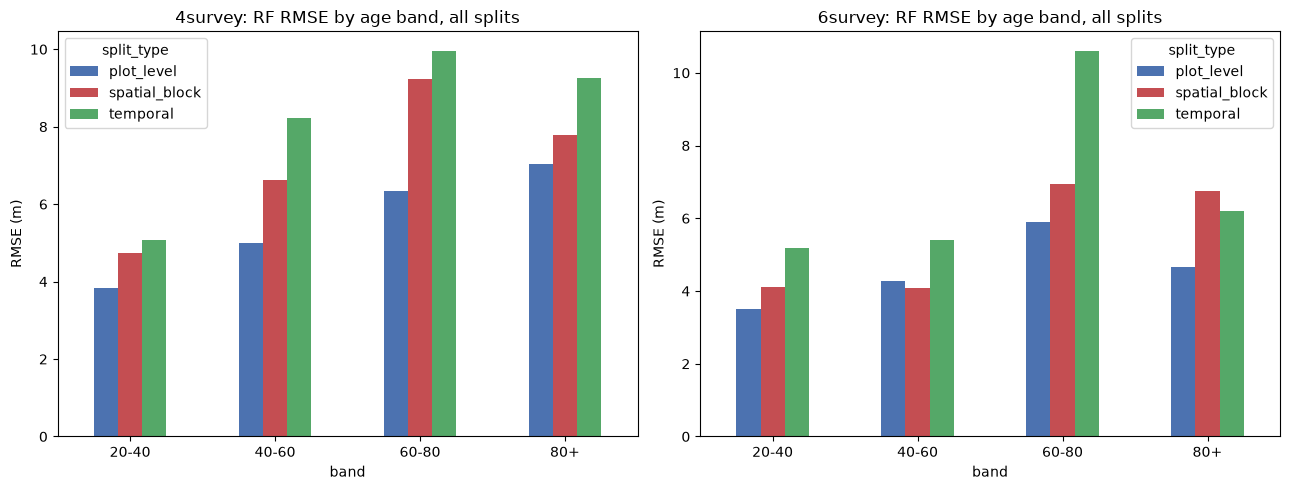

In [58]:
rf_band_rows = []
for cohort in COHORTS:
    for split_type in SPLIT_TYPES:
        for band in generalization_metrics[("rf_baseline", cohort, split_type)].get("age_bands", []):
            rf_band_rows.append({
                "cohort": cohort,
                "split_type": split_type,
                "band": band["band"],
                "n_rows": band["n_rows"],
                "RMSE": band["rmse"],
                "Bias": band["bias"],
            })

rf_band_df = pd.DataFrame(rf_band_rows)

fig, axes = plt.subplots(1, len(COHORTS), figsize=(13, 5))
for ax, cohort in zip(axes, COHORTS):
    cohort_bands = rf_band_df[rf_band_df["cohort"] == cohort]
    pivoted = cohort_bands.pivot(index="band", columns="split_type", values="RMSE")
    band_order = [b for b in ["20-40", "40-60", "60-80", "80+"] if b in pivoted.index]
    pivoted = pivoted.loc[band_order, SPLIT_TYPES]

    pivoted.plot(kind="bar", ax=ax, color=["#4c72b0", "#c44e52", "#55a868"])
    ax.set_title(f"{cohort}: RF RMSE by age band, all splits")
    ax.set_ylabel("RMSE (m)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 11. Progress so far

- **Data pipeline**: cleaned, balanced 4survey (71,766 plots) and 6survey (13,897 plots) Sitka
  cohorts exported from the raw GeoPackage, target `Top_Height99` (fallback `Top_Height95`).
  Filtering is a per-plot maturity gate, not a per-row threshold: a plot's actual Age at its 2023
  survey must be >= 30, or the whole plot (every survey year) is dropped; yield class 2-50 is
  still applied per row. See `models/common/data.py::filter_data`.
- **Split infrastructure**: `plot_level_split()`, `spatial_block_split()` (compartment-based,
  size-aware, asymmetric train-only buffering), and `temporal_split()` (chronological holdout,
  `TEMPORAL_YEARS` in `models/common/splits.py`) all now wired into
  `run_baselines.py`/`evaluate_baselines.py` via `--split-type`.
- **Four baselines fitted and evaluated on all three split types**: Chapman-Richards,
  average-by-age, linear regression, random forest (no environmental features yet, so no spatial
  leakage risk at this stage).
- **Survey-year confound quantified**: `models/chapman_richards/year_effect_diagnostic.py`
  (diagnostic only, never in the model-comparison tables) puts a number on the growth-curve
  plot's year confound — real (up to +6.86m `y_max` shift in 4survey) but small relative to total
  residual variance (2.06% of squared error in 4survey, 4.74% in 6survey). Most residual variance
  is unexplained by year alone.
- **RF spatial generalization gap confirmed, temporal generalization is a much bigger effect
  (section 10)**: RF was the best model of the four on `plot_level_split` in both cohorts, but had
  the largest RMSE degradation of any model under `spatial_block_split` (+28.7% in 4survey, +19.4%
  in 6survey) — a partial replication of Lynch (2025)'s finding, though not yet proof of their
  specific terrain-interpolation mechanism (no terrain features exist yet). Under `temporal_split`
  (predict 2023 having trained on 2008-2012 only), every model degrades far more severely —
  6survey's `average_by_age` degrades +141.7% and goes R² negative — and Chapman-Richards, not RF,
  is the most temporally robust model in relative terms, the opposite ranking from the spatial
  test.
- **Trajectory / transition data extended**: `data_processing/export_model_tables.py`'s
  `build_transition_table()` now carries previous-survey values of every no-environment feature
  (`previous_Thin`, `previous_time_since_thinning`, etc.), not just Age/height/canopy cover —
  needed for the PINN's trajectory loss (below).
- **DNN and PINN (no-environment feature set): done, tuned, and beating every baseline above.**
  Both trained under `spatial_block_split` (the dissertation's primary split) and `temporal_split`
  (secondary), with a real hyperparameter search behind the numbers, not just the first run's
  defaults. Headline: DNN RMSE 5.02/3.65 (4survey/6survey), PINN RMSE 5.12/3.63 — both comfortably
  below RF's best-of-baselines 4.65/3.86 from `plot_level_split` above, on a *harder* split. Full
  detail, loss curves, and the physics/trajectory-weight tuning: see
  `results_notebooks/baseline_models_parameter_tuning.ipynb`. See section 12 below for what this
  means for the dissertation, not just the numbers.
- **Not started yet**: terrain/wind features, XGBoost + SHAP, Env-PINN. Once terrain features and
  Env-PINN results exist, re-run the section 10 three-way comparison on them and check whether
  Env-PINN's spatial- and temporal-holdout degradation is smaller than RF's and Chapman-Richards'
  current best-in-class results respectively.

See `documentation/plans_md/Dissertation Plan v5 - 7th June.md` ("Implementation Status" section)
for the fuller narrative version of this.

In [ ]:
## 12. Where this fits in the dissertation's bigger picture

Not hyperparameter detail (see `baseline_models_parameter_tuning.ipynb` for that) — stepping
back to what the DNN/PINN result actually means for the argument this dissertation is making.

**1. DNN and PINN both beat every baseline here, on a harder split than the one shown above.**
Sections 1-9 report `plot_level_split` (the easy test); DNN/PINN were evaluated under
`spatial_block_split` (whole compartments held out) and still beat RF's best `plot_level_split`
number. That's a stronger result than it looks like side by side — a fair like-for-like comparison
would need RF re-run under `spatial_block_split` too (already done in section 10: RF's RMSE there
is 5.99/4.60, clearly behind both DNN and PINN).

**2. The physics constraint, at full strength, hurts rather than helps — and that's informative,
not a failure.** `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` had been fixed at `1.0` (untested) since the
PINN was built. Sweeping this found PINN does *better* the *weaker* the physics constraint is —
4survey's best result is physics fully off. Why: Chapman-Richards uses one global `y_max` for
every plot. Forcing the network to match that single curve as strongly as it's forced to match
real observed heights fights against real plot-to-plot variation — which is exactly the variation
this dissertation exists to explain, not noise to suppress.

**3. This connects directly to Yield Class.** Forest Research's `yldc` field (General Yield Class,
GYC) is the industry-standard version of the same idea as CR's `y_max` — a single number meant to
summarise a stand's growth ceiling. The two are directly linked: Aberfoyle's typical Sitka GYC
range (8–20) corresponds to an implied CR `y_max` of ~28–50m. Worrell (1987) already found Yield
Class varies substantially with terrain in Scottish upland sites (3.2–4.0 m³/ha/yr decline per
100m elevation gain) — meaning a single assigned Yield Class per stand is likely too coarse for
real within-forest variation, the same gap the physics-weight sweep just found empirically for
CR's `y_max`.

**4. This is the direct case for Env-PINN, not just a theoretical one.** Env-PINN's whole design —
replacing CR's single global `y_max` with a learned, plot-specific `y_max(terrain, wind)` — is
effectively *re-deriving Yield Class at finer spatial resolution than Forest Research currently
assigns it*, directly from measured LiDAR growth trajectories rather than a coarse yield table.
The no-env PINN result above isn't just "a model that works" — it's evidence that the single-value
assumption underlying both CR and Yield Class breaks down, motivating exactly the fix Env-PINN is
built to provide.

**5. What's next.** No-env DNN/PINN tuning is done (`physics_weight = trajectory_weight = 0.05`
chosen as the shared default). Next: extract terrain/wind features per plot, run XGBoost + SHAP
on CR residuals to identify which features actually explain them, then build Env-PINN's
environmental sub-network. Volume (`Vol95`/`Vol99`) stays excluded as a *predictor* here (it's
derived from height/age, a leakage risk) but is the natural way to translate Env-PINN's eventual
spatial `y_max` map back into Yield-Class-equivalent terms a forestry audience recognises — a
Chapter 5/6 output, not something needed now.

Full reasoning and numbers: `documentation/experiment_log.md`'s 2026-07-17 Findings entries.